### Задача 1: Предсказание качества вина и оценка важности признаков

Эта задача покажет, как Random Forest помогает понять структуру данных.

- **Датасет:** Скачать с Kaggle популярный датасет **"Red Wine Quality"** (`winequality-red.csv`). Целевая переменная — `quality` (оценка от 3 до 8).
- **Что нужно сделать:**
    1. Перевести задачу в бинарную классификацию: если `quality >= 7`, то вино хорошее (`1`), иначе среднее/плохое (`0`).
    2. Разбить выборку на Train и Test (80/20). **Важно:** Random Forest не требует масштабирования признаков через `StandardScaler`!
    3. Обучить `RandomForestClassifier(n_estimators=100, random_state=42)`.
    4. Посчитать `accuracy_score` и `classification_report`. Сравнить точность с одиночным деревом решений (`DecisionTreeClassifier`), обученным на тех же данных.
    5. Вывести важность признаков с помощью `model.feature_importances_`. Построить горизонтальный столбчатый график (bar chart), где по оси Y будут названия химических свойств вина, а по оси X — их важность для модели. Какое вещество сильнее всего влияет на то, признают ли вино хорошим?

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("winequality-red.csv")

df = df.dropna()
df = df.drop_duplicates()
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [120]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [122]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)

dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=500, random_state=42)


rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [124]:
train_accuracy = rf_model.score(X_train, y_train)
print("Random Forest Training Accuracy:", train_accuracy)

test_accuracy = rf_model.score(X_test, y_test)
print("Random Forest Test Accuracy:", test_accuracy)

dt_train_accuracy = dt_model.score(X_train, y_train)
print("Decision Tree Training Accuracy:", dt_train_accuracy)

dt_test_accuracy = dt_model.score(X_test, y_test)
print("Decision Tree Test Accuracy:", dt_test_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.6470588235294118
Decision Tree Training Accuracy: 0.5850965961361545
Decision Tree Test Accuracy: 0.5257352941176471


Text(0.5, 1.0, 'Feature Importance in Random Forest Model')

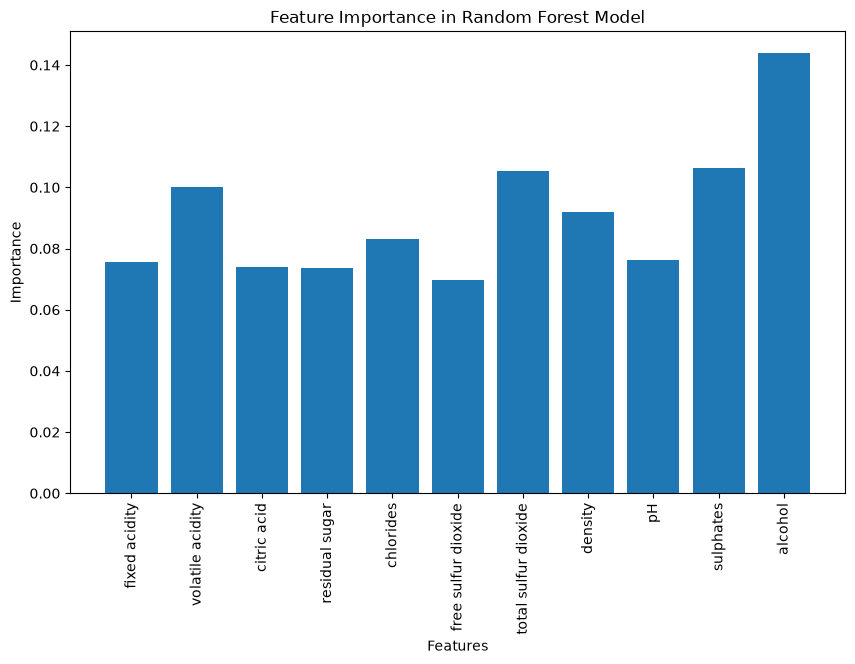

In [125]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(rf_model.feature_importances_)), rf_model.feature_importances_)
plt.xticks(range(len(rf_model.feature_importances_)), X.columns, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")

### Задача 2: Оценка Out-of-Bag (Валидация без тестовой выборки)

Эта задача продемонстрирует уникальное свойство бэггинга, позволяющее экономить данные для тестирования.

- **Датасет:** Использовать датасет цен на недвижимость в Калифорнии (`sklearn.datasets.fetch_california_housing`).
- **Что нужно сделать:**
    
    1. Взять первые 3000 строк датасета.
    2. Обучить `RandomForestRegressor` на **всех** этих данных (не разделяя на Train/Test!), но обязательно включить параметр `oob_score=True`:
        ```
        rf = RandomForestRegressor(n_estimators=150, oob_score=True, random_state=42)
        rf.fit(X, y)
        ```
    3. Вывести значение `rf.oob_score_` (для регрессии это коэффициент детерминации $R^2$).
    4. Теперь классическим образом разделить эти же данные на Train/Test (80/20), обучить точно такую же модель на Train-выборке и посчитать $R^2$ на Test-выборке с помощью `.score(X_test, y_test)`.
    5. Сравнить эти два значения. Объяснить, почему OOB-оценка так близка к честной оценке на тест-выборке.

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

df = sklearn.datasets.fetch_california_housing(as_frame=True).frame

df = df.dropna()
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [127]:
df2 = df.head(3000)
X = df2.drop("MedHouseVal", axis=1)
y = df2["MedHouseVal"]

In [128]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)

rf_model.fit(X, y)

print("OOB Score:", rf_model.oob_score_)

OOB Score: 0.8627635717890189


In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [130]:
rf_model2 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)

rf_model2.fit(X_train, y_train)

print("OOB Score:", rf_model2.oob_score_)
print("Test Score:", rf_model2.score(X_test, y_test))

OOB Score: 0.8505610456250906
Test Score: 0.8772683399760237


### Задача 3: Экстраполяция регрессии (Почему лес — не линейная модель?)

Эта задача наглядно покажет фундаментальную разницу между линейными моделями и деревьями в предсказании будущего.

- **Условие:** Сгенерировать данные с явным временным трендом (например, рост акций или цен со временем):
    ```
    import numpy as np
    X = np.arange(1, 100).reshape(-1, 1)
    y = 2 * X.ravel() + np.random.normal(0, 5, 99) # линейный рост с шумом
    ```
- **Что нужно сделать:**
    1. Разделить данные по времени: первые 80 точек взять как Train, а оставшиеся 19 точек (где $X$ от 81 до 99) — как Test.
    2. Обучить на Train две модели: `LinearRegression` и `RandomForestRegressor(n_estimators=100)`.
    3. Сделать предсказание для всего диапазона $X$ (от 1 до 100) обеими моделями.
    4. Построить график: scatter-точки исходных данных, линия предсказания линейной регрессии и линия предсказания Случайного леса.
    5. Посмотреть, как ведет себя Случайный лес на тестовом отрезке (где значения $X$ больше тех, что он видел при обучении). Почему его предсказания превратились в горизонтальную прямую, в то время как линейная регрессия продолжила расти? Описать этот эффект.

In [131]:
import numpy as np
X = np.arange(1, 100).reshape(-1, 1)
y = 2 * X.ravel() + np.random.normal(0, 5, 99) # линейный рост с шумом

In [132]:
from sklearn.model_selection import train_test_split

X_train = X[:80]
X_test = X[80:]
y_train = y[:80]
y_test = y[80:]

In [133]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [134]:
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

Text(0.5, 1.0, 'Model Predictions vs Actual Data')

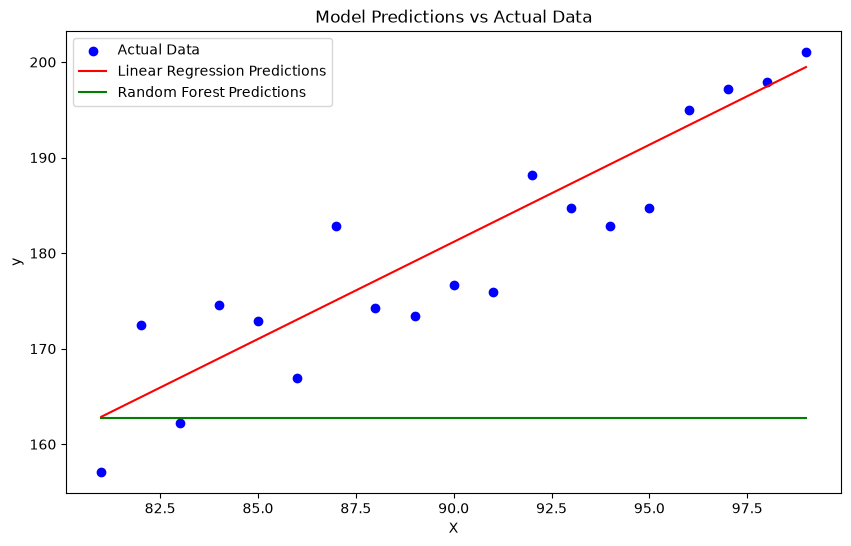

In [135]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_lr, color='red', label='Linear Regression Predictions')
plt.plot(X_test, y_pred_rf, color='green', label='Random Forest Predictions')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Model Predictions vs Actual Data')